<a href="https://colab.research.google.com/github/shanfty/CS_5265_ML_Project/blob/main/CS_5262_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook for ML


Describe my project in a text cell including the following sections:


Background

The Dataset will be looking at a popular online car marketplace known as cars.com. The dataset is from kaggle.com, https://www.kaggle.com/datasets/chancev/carsforsale There is around 9000 data points for different cars including their descriptions and prices for the listings.


Project Description

The project will first be to clean up data, to make sure all the variables can be transformed into the correct class. Looking at the car's features and predicting a price, or vice versa. Taking in some examples of certain features of a car and its price and guessing which other features it has or the ratings it has on the cars.com catelog. Can even look into private vs dealership sales and the different between features & prices of the two. Most likely creating a regression model that predicts a car's price. Future steps could be to look at past years catelogs to see how much the market has been effected from the last couple of years for inflation wise.


Performance Metrix

Looking at the predicted valuation of the car vs the actual price listed. Need to have a range and not be exact because listing price does not neccessarly mean its worth that much or little. Thinking plus or mins $250 to determine if the predicted value is successful. Then look at all the success to find the accuracy of the algorithm. 


## Importing Libraries

In [146]:
# tables and visualizations
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer, StandardScaler
from sklearn import config_context
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Loading Data

In [147]:
data_dictionary = pd.read_csv("https://docs.google.com/spreadsheets/d/1A5GPct-AqzSzEFbDWKczS6eKnS3zTV3cLkyWxNBYKrA/export?format=csv&grid=")

display(data_dictionary)

,Feature,Description
0,Year,What year the car model was made in. Stander 4...
1,Make,"The dealer of the car, who created the company..."
2,Model,"The model of the car, Spaces and dashes used n..."
3,Used/New,"String 2 options, 'used' or 'certified'"
4,Price,"Price of the car following this format $xxx,xxx"
5,ConsumerRating,Rating that the consumer of the car has given ...
6,ConsumerReviews,How many reviews consumers have given. Straigh...
7,SellerType,"Sold from a dealer or private individual, 2 st..."
8,SellerName,"The name of the Seller, can be pretty long wit..."
9,SellerRating,The rating the seller gives to the vehicle 0.0...


In [175]:
cars = pd.read_csv("https://docs.google.com/spreadsheets/d/1L-jeVC6ujsiOxCZ578ngfKm1iuimJOyw8HOz765WVOM/export?format=csv&grid=")
cars = cars.drop('StreetName', axis=1)
cars = cars.drop('SellerName', axis=1)
cars = cars.drop('Stock#', axis=1)
cars = cars.drop('VIN', axis=1)              
cars = cars.dropna(subset=['DealType'])

display(cars.tail(5))
cars.info()

,Year,Make,Model,Used/New,Price,ConsumerRating,ConsumerReviews,SellerType,SellerRating,SellerReviews,...,ReliabilityRating,ExteriorColor,InteriorColor,Drivetrain,MinMPG,MaxMPG,FuelType,Transmission,Engine,Mileage
9374,2019,Subaru,Crosstrek 2.0i Premium,Used,"$27,374",4.7,205,Dealer,4.4,443,...,4.8,Quartz Blue Pearl,Gray,All-wheel Drive,27,33,Gasoline,Automatic CVT,2.0L H4 16V GDI DOHC,15606
9375,2019,Audi,Q8 3.0T Premium,Used,"$61,998",4.8,27,Dealer,4.8,1789,...,4.9,Night Black,Black,All-wheel Drive,17,22,Hybrid,8-Speed Automatic,3.0L V6 24V GDI DOHC Turbo Hybrid,46855
9376,2017,Buick,Enclave Leather,Used,"$26,944",4.8,137,Dealer,4.7,831,...,4.8,Ebony Twilight Metallic,Ebony,All-wheel Drive,15,22,Gasoline,6-Speed Automatic,3.6L V6 24V GDI DOHC,62649
9377,2019,Subaru,Forester Premium,Used,"$28,568",4.7,279,Dealer,4.4,680,...,4.8,Crystal Black Silica,Black,All-wheel Drive,26,33,Gasoline,Automatic CVT,2.5L H4 16V GDI DOHC,30760
9378,2019,Hyundai,Santa Fe Ultimate 2.4,Used,"$32,091",4.8,204,Dealer,4.4,1105,...,4.8,Twilight Black,Black,All-wheel Drive,21,27,Gasoline,8-Speed Automatic,2.4L I4 16V GDI DOHC,41645


<class 'pandas.core.frame.DataFrame'>
Int64Index: 9157 entries, 0 to 9378
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   9157 non-null   int64  
 1   Make                   9157 non-null   object 
 2   Model                  9157 non-null   object 
 3   Used/New               9157 non-null   object 
 4   Price                  9157 non-null   object 
 5   ConsumerRating         9157 non-null   float64
 6   ConsumerReviews        9157 non-null   int64  
 7   SellerType             9157 non-null   object 
 8   SellerRating           9157 non-null   float64
 9   SellerReviews          9157 non-null   int64  
 10  State                  9157 non-null   object 
 11  Zipcode                9157 non-null   object 
 12  DealType               9157 non-null   object 
 13  ComfortRating          9157 non-null   float64
 14  InteriorDesignRating   9157 non-null   float64
 15  Perf

In [149]:
cars['Drivetrain'].value_counts()

All-wheel Drive      4476
Front-wheel Drive    2329
Four-wheel Drive     1549
Rear-wheel Drive      915
FWD                    36
AWD                    34
4WD                    20
RWD                    12
–                       7
Front Wheel Drive       1
Name: Drivetrain, dtype: int64

## Feature Engineering

Interior Colors keeping primary colors such as; Red, Black, White, Blue, Brown, Gray

Exterior Colors keeping most common colors

### Interior Colors
Changing all colors that don't occur at least 25 times & weird string of 'â€“' to other.

In [150]:
Remove = ['–']

value_counts = cars['InteriorColor'].value_counts()
to_remove = value_counts[value_counts <= 24].index

cars['InteriorColor'] = cars['InteriorColor'].apply(lambda x: x if x not in to_remove else 'Other')
cars['InteriorColor'] = cars['InteriorColor'].apply(lambda x: x if x not in Remove else 'Other')

cars['InteriorColor'].value_counts()


Black                   3758
Other                   2506
Jet Black                486
Gray                     420
Ebony                    412
Charcoal                 214
Graphite                 204
Beige                    200
Ivory                    110
Red                      107
Parchment                 99
Charcoal Black            70
Titan Black               67
Ebony / Ebony             64
Brown                     57
Tan                       50
Canberra Beige            49
Ebony Black               44
Ash                       41
Shara Beige               40
Ivory White               39
White                     39
White / Black             36
Cognac                    35
Wheat                     35
Mocha                     34
Cappuccino                31
Okapi Brown               27
Satin Black               27
Macchiato Beige           27
Almond                    26
Nougat Brown / Black      25
Name: InteriorColor, dtype: int64

Black                   3758
Other                   2506
Jet Black                486
Gray                     420
Ebony                    412
Charcoal                 214
Graphite                 204
Beige                    200
Ivory                    110
Red                      107
Parchment                 99
Charcoal Black            70
Titan Black               67
Ebony / Ebony             64
Brown                     57
Tan                       50
Canberra Beige            49
Ebony Black               44
Ash                       41
Shara Beige               40
Ivory White               39
White                     39
White / Black             36
Cognac                    35
Wheat                     35
Mocha                     34
Cappuccino                31
Okapi Brown               27
Satin Black               27
Macchiato Beige           27
Almond                    26
Nougat Brown / Black      25
Name: InteriorColor, dtype: int64

([<matplotlib.patches.Wedge at 0x7ffaae254890>,
 [Text(0.3376751618220957, 1.0468884778659195, 'Black'),
  Text(-1.0745848817265928, -0.23509005075639552, 'Other'),
  Text(-0.38050830933163843, -1.0320917723388645, 'Jet Black'),
  Text(-0.05469312483709342, -1.098639459556935, 'Gray'),
  Text(0.24964566682685105, -1.071296896772588, 'Ebony'),
  Text(0.46717009309313606, -0.9958675133366641, 'Charcoal'),
  Text(0.6015781017774662, -0.9209255059242418, 'Graphite'),
  Text(0.7203215528987312, -0.8313464142158553, 'Beige'),
  Text(0.8026117374158912, -0.7522063539762509, 'Ivory'),
  Text(0.8551194774727567, -0.6919325684246403, 'Red'),
  Text(0.9007912957200832, -0.6313279983930175, 'Parchment'),
  Text(0.9350677036712755, -0.5793516976335946, 'Charcoal Black'),
  Text(0.9606601840606017, -0.5358470031274328, 'Titan Black'),
  Text(0.9832408014022528, -0.4931911662406941, 'Ebony / Ebony'),
  Text(1.0024169913622645, -0.45294610653832296, 'Brown'),
  Text(1.0180036815495332, -0.416735532864

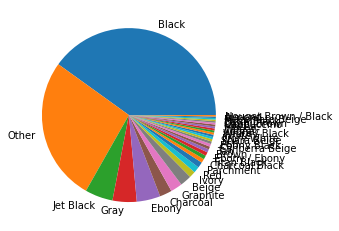

In [151]:
InteriorColor_Count = cars['InteriorColor'].value_counts()
display(InteriorColor_Count)

plt.pie(InteriorColor_Count, labels=InteriorColor_Count.index)

### Exterior Colors

Changing all colors that don't occur at least 25 times & weird string of 'â€“' to other.

In [152]:
value_counts_exterior = cars['ExteriorColor'].value_counts()
to_remove_exterior = value_counts_exterior[value_counts_exterior <= 24].index

cars['ExteriorColor'] = cars['ExteriorColor'].apply(lambda x: x if x not in to_remove_exterior else 'Other')
cars['ExteriorColor'] = cars['ExteriorColor'].apply(lambda x: x if x not in Remove else 'Other')

cars['ExteriorColor'].value_counts()

Other                      3365
Black                       897
White                       340
Gray                        320
Diamond Black               200
                           ... 
Galactic Aqua                26
Manhattan Gray Metallic      26
Pure White                   26
Magnetic Black               25
Florett Silver Metallic      25
Name: ExteriorColor, Length: 88, dtype: int64

### Drive Train

Changing to FWD, AWD, RWD, 4WD

In [153]:
cars.loc[(cars.Drivetrain == 'Four-wheel Drive'),'Drivetrain']='4WD'
cars.loc[(cars.Drivetrain == 'Front-wheel Drive'),'Drivetrain']='FWD'
cars.loc[(cars.Drivetrain == 'All-wheel Drive'),'Drivetrain']='AWD'
cars.loc[(cars.Drivetrain == 'Rear-wheel Drive'),'Drivetrain']='RWD'

Drivetrain_remove = ['4WD', 'AWD', 'RWD', 'FWD']
cars = cars[cars.Drivetrain.isin(Drivetrain_remove)]
cars['Drivetrain'].value_counts()

AWD    4510
FWD    2365
4WD    1569
RWD     927
Name: Drivetrain, dtype: int64

### Used/New

This is showing used or [make] certified. I.E. 'Dodge Certified' So there is multiple entries for each brand when in reality it should just read new, change all these to new or just certified we already have a make field. 

In [154]:
cars['Used/New'] = cars['Used/New'].apply(lambda x: x if x in 'Used' else 'New')

cars['Used/New'].value_counts()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


Used    7892
New     1479
Name: Used/New, dtype: int64

### FuelType

Changing all '–' to 'other'.

In [155]:
cars.loc[(cars.FuelType == '–'),'FuelType']='Other'

cars['FuelType'].value_counts()


/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


Gasoline                         8899
Electric                          162
E85 Flex Fuel                     120
Hybrid                             69
Diesel                             45
Other                              30
Gasoline Fuel                      29
Electric Fuel System                5
Gasoline/Mild Electric Hybrid       5
Flex Fuel Capability                3
Flexible Fuel                       2
Plug-In Electric/Gas                1
Diesel Fuel                         1
Name: FuelType, dtype: int64

### Transmission

Returning Either Automatic or manual

In [163]:
cars.loc[cars['Transmission'].str.contains('Automatic', case=False), 'Transmission'] = 'Automatic'
cars.loc[cars['Transmission'].str.contains('Manual', case=False), 'Transmission'] = 'Manual'
cars_other = ['Automatic', 'Manual']
cars['Transmission'] = cars['Transmission'].apply(lambda x: x if x in cars_other else 'Manual')


cars['Transmission'].value_counts()

Automatic    9163
Manual        208
Name: Transmission, dtype: int64

### Price

Removing the '$' as the start and removing all commas

In [179]:
cars.Price= cars.Price.str.replace(',','')
cars.Price= cars.Price.str.replace('$','')

cars['Price'].value_counts()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  


29995    36
42998    30
38998    29
31998    29
39998    28
         ..
38351     1
31968     1
35738     1
29894     1
32091     1
Name: Price, Length: 4942, dtype: int64

## ML Pipeline
Standardization for variables, Choosing what models to show the data. Cycling through pipelines add more to transform data based on the models or adding new features.

In [180]:
X_df = cars.drop(columns='Price')
y = cars['Price'].values

In [184]:
encoder = OneHotEncoder()
X = encoder.fit_transform(X_df.values)

In [185]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=2019
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8241, 15209)
(916, 15209)
(8241,)
(916,)


In [159]:
#individual pipelines for differing datatypes
cat_pipeline = Pipeline(steps=[('cat_impute', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
                               ('onehot_cat', OneHotEncoder(drop='if_binary'))])
num_pipeline = Pipeline(steps=[('impute_num', SimpleImputer(missing_values=np.nan, strategy='mean')),
                               ('scale_num', StandardScaler())])

In [160]:
#establish preprocessing pipeline by columns
preproc = ColumnTransformer([('cat_pipe', cat_pipeline, make_column_selector(dtype_include=object)),
                             ('num_pipe', num_pipeline, make_column_selector(dtype_include=np.number))],
                             remainder='passthrough')

In [161]:
#generate the whole modeling pipeline with preprocessing
pipe = Pipeline(steps=[('preproc', preproc),
                       ('mdl', LogisticRegression(penalty='elasticnet', solver='saga', tol=0.01))])

#visualization for steps
with config_context(display='diagram'):
    display(pipe)

Pipeline(steps=[('preproc',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_pipe',
                                                  Pipeline(steps=[('cat_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot_cat',
                                                                   OneHotEncoder(drop='if_binary'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ffaae4f59d0>),
                                                 ('num_pipe',
                                                  Pipeline(steps=[('impute_num',
                                                                   SimpleImputer()),
                                                                  ('scale_num',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ffaae4f5890>)])),
                ('mdl',
                 LogisticRegression(penalty='elasticnet', solver='saga',
                                    tol=0.01))])